In [6]:
from datasets import load_dataset

/Users/yasir/Desktop/workspace/health-insurance/ocr_module/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
dataset = load_dataset(path =  "amaye15/invoices-google-ocr", split=None, cache_dir= "../data")

In [7]:
dataset

DatasetDict({
    train: Dataset({
        features: ['pixel_values', 'label', 'ocr'],
        num_rows: 13463
    })
    test: Dataset({
        features: ['pixel_values', 'label', 'ocr'],
        num_rows: 3366
    })
})

In [ ]:
print("Dataset splits:", list(dataset.keys()))
print("\nTrain split info:")
print(f"Number of examples: {len(dataset['train'])}")
print(f"Features: {dataset['train'].features}")
print(f"\nTest split info:")
print(f"Number of examples: {len(dataset['test'])}")
print(f"Features: {dataset['test'].features}")

Dataset splits: ['train', 'test']

Train split info:
Number of examples: 13463
Features: {'pixel_values': Image(mode=None, decode=True), 'label': ClassLabel(names=['Barcode', 'Invoice', 'Object', 'Receipt', 'Non-Object']), 'ocr': List({'bounding box': {'vertex 0': {'x': Value('int64'), 'y': Value('int64')}, 'vertex 1': {'x': Value('int64'), 'y': Value('int64')}, 'vertex 2': {'x': Value('int64'), 'y': Value('int64')}, 'vertex 3': {'x': Value('int64'), 'y': Value('int64')}}, 'text': Value('string')})}

Test split info:
Number of examples: 3366
Features: {'pixel_values': Image(mode=None, decode=True), 'label': ClassLabel(names=['Barcode', 'Invoice', 'Object', 'Receipt', 'Non-Object']), 'ocr': List({'bounding box': {'vertex 0': {'x': Value('int64'), 'y': Value('int64')}, 'vertex 1': {'x': Value('int64'), 'y': Value('int64')}, 'vertex 2': {'x': Value('int64'), 'y': Value('int64')}, 'vertex 3': {'x': Value('int64'), 'y': Value('int64')}}, 'text': Value('string')})}


In [8]:
example = dataset['train'][0]
print("Example keys:", list(example.keys()))
print("\nExample content:")
for key, value in example.items():
    print(f"{key}: {str(value)[:100]}..." if len(str(value)) > 100 else f"{key}: {value}")

Example keys: ['pixel_values', 'label', 'ocr']

Example content:
pixel_values: <PIL.PngImagePlugin.PngImageFile image mode=RGB size=595x841 at 0x13B8DEBA0>
label: 1
ocr: [{'bounding box': {'vertex 0': {'x': 12, 'y': 27}, 'vertex 1': {'x': 566, 'y': 27}, 'vertex 2': {'x'...


In [12]:
label_names = dataset['train'].features['label'].names
all_labels = list(dataset['train']['label'])

samples = {}
for i, name in enumerate(label_names):
    if i in all_labels:
        samples[name] = all_labels.index(i)

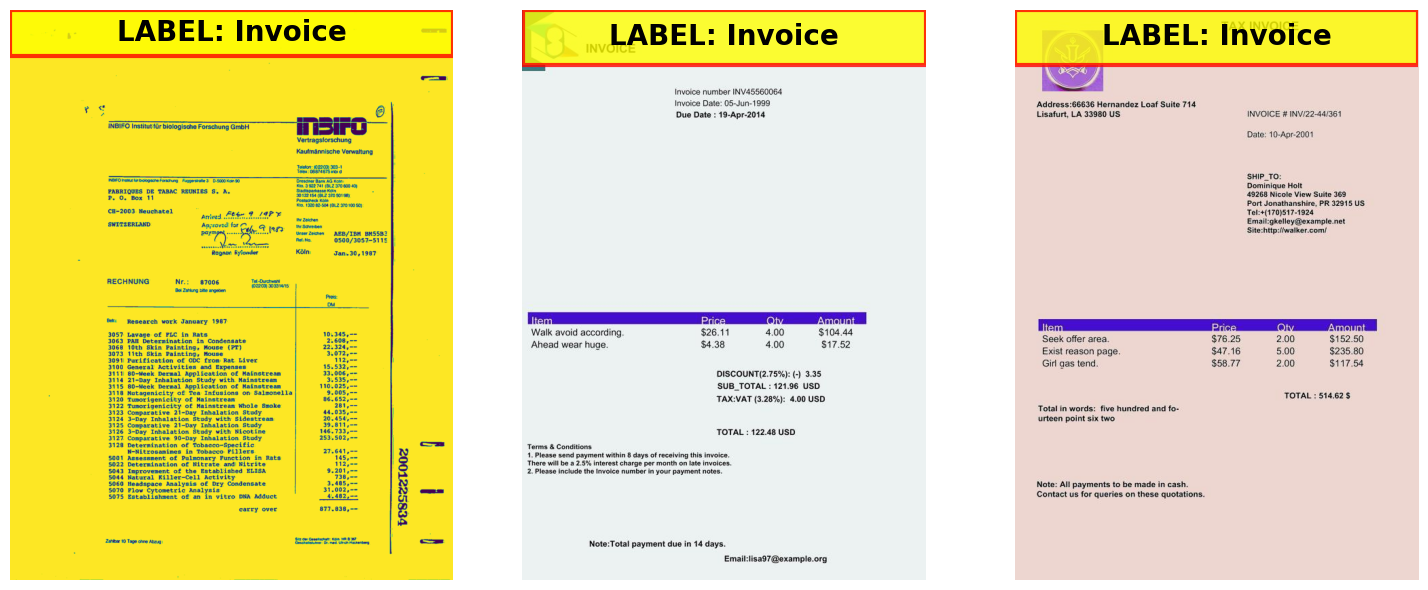

In [13]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import random

label_names = dataset['train'].features['label'].names
all_labels = list(dataset['train']['label'])

samples = []
for i, name in enumerate(label_names):
    indices = [idx for idx, lbl in enumerate(all_labels) if lbl == i]
    if indices:
        num_samples = random.randint(2, 3)
        samples.extend([(name, idx) for idx in random.sample(indices, min(num_samples, len(indices)))])

# Shuffle for random order
random.shuffle(samples)

fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 6))
if len(samples) == 1:
    axes = [axes]

for idx, (label, sample_idx) in enumerate(samples):
    img = dataset['train'][sample_idx]['pixel_values']
    axes[idx].imshow(img)
    w, h = img.size
    rect = Rectangle((0, 0), w, 80, linewidth=3, edgecolor='red', 
                     facecolor='yellow', alpha=0.8, zorder=10)
    axes[idx].add_patch(rect)
    axes[idx].text(w/2, 40, f'LABEL: {label}', ha='center', va='center',
                   fontsize=20, fontweight='bold', color='black', zorder=11)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


In [14]:
type(img)

PIL.PngImagePlugin.PngImageFile

In [15]:
import sys
import os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd())))
from call import encode_image, infer

In [16]:
encoded_img = encode_image(img)

In [17]:
encoded_img

'...'

In [ ]:
response = infer(encoded_img)

In [ ]:
response